In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import sys
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

sys.path.append('..')
from src.data_loader import DataLoader
from src.preprocessing import TimeSeriesPreprocessor
from src.evaluation import Evaluator
from src.arima_model import TimeSeriesARIMA
from src.visualization import Visualizer
from src.lstm_model import TimeSeriesLSTM


In [2]:
files = {
    "TSLA": "../data/processed/TSLA_processed.csv",
    "SPY": "../data/processed/SPY_processed.csv",
    "BND": "../data/processed/BND_processed.csv"
}

raw_data = {}

for name, path in files.items():

    loader = DataLoader(path)
    df = loader.load_data()

    raw_data[name] = df

    print(f"{name} loaded -> {df.shape}")

TSLA loaded -> (2888, 11)
SPY loaded -> (2888, 11)
BND loaded -> (2888, 11)


In [3]:
preprocessor = TimeSeriesPreprocessor()

clean_data = {}

for name, df in raw_data.items():

    df = preprocessor.clean_data(df)

    clean_data[name] = df

    print(f"{name} cleaned -> {df.shape}")

TSLA cleaned -> (2888, 11)
SPY cleaned -> (2888, 11)
BND cleaned -> (2888, 11)


In [4]:
train_data = {}
test_data = {}

for name, df in clean_data.items():

    train, test = preprocessor.train_test_split(df)

    train_data[name] = train
    test_data[name] = test

    print(f"{name}")
    print("Train:", train.shape, "Test:", test.shape)

TSLA
Train: (2310, 11) Test: (578, 11)
SPY
Train: (2310, 11) Test: (578, 11)
BND
Train: (2310, 11) Test: (578, 11)


In [5]:
arima_train = {}
arima_test = {}

for name in clean_data.keys():

    arima_train[name] = train_data[name]["Daily_Return"].dropna()
    arima_test[name] = test_data[name]["Daily_Return"].dropna()

    print(f"{name} ARIMA ready")

TSLA ARIMA ready
SPY ARIMA ready
BND ARIMA ready


In [6]:
lstm_train = {}
lstm_test = {}
scalers = {}

for name in clean_data.keys():

    train_scaled, test_scaled, scaler = preprocessor.scale_close(
        train_data[name],
        test_data[name],
        col="Close"
    )

    lstm_train[name] = train_scaled
    lstm_test[name] = test_scaled
    scalers[name] = scaler

    print(f"{name} scaled for LSTM")

TSLA scaled for LSTM
SPY scaled for LSTM
BND scaled for LSTM


In [7]:
window = 60

lstm_sequences = {}

for name in clean_data.keys():

    X_train, y_train = preprocessor.create_sequences(
        lstm_train[name],
        window
    )

    X_test, y_test = preprocessor.create_sequences(
        np.concatenate([lstm_train[name][-window:], lstm_test[name]]),
        window
    )

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    lstm_sequences[name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test
    }

    print(f"{name} sequences created")

TSLA sequences created
SPY sequences created
BND sequences created


In [8]:
summary = []

for name in clean_data.keys():

    summary.append({
        "Dataset": name,
        "Train Shape": train_data[name].shape,
        "Test Shape": test_data[name].shape,
        "ARIMA Target": "Daily_Return",
        "LSTM Target": "Close (Scaled)"
    })

import pandas as pd
pd.DataFrame(summary)

,Dataset,Train Shape,Test Shape,ARIMA Target,LSTM Target
0,TSLA,"(2310, 11)","(578, 11)",Daily_Return,Close (Scaled)
1,SPY,"(2310, 11)","(578, 11)",Daily_Return,Close (Scaled)
2,BND,"(2310, 11)","(578, 11)",Daily_Return,Close (Scaled)


Seasonal Analysis
Financial daily return series generally do not exhibit strong fixed seasonality.
Therefore, ARIMA was selected instead of SARIMA.

In [9]:
arima_model = TimeSeriesARIMA()
evaluator = Evaluator()
viz = Visualizer()

In [10]:
arima_results = {}
comparison = []


Dataset: TSLA


c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Best Order: (2, 0, 2)
MAE : 46.85688792475316
RMSE: 65.7795700219751
MAPE: 13.189403781782072


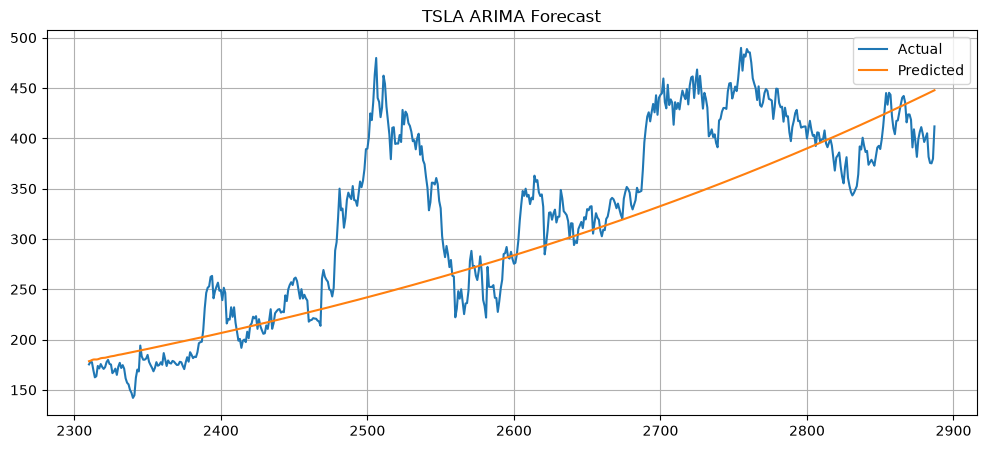


Dataset: SPY


c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best Order: (3, 0, 2)
MAE : 32.30948426313095
RMSE: 39.33207994997608
MAPE: 5.030780669762759


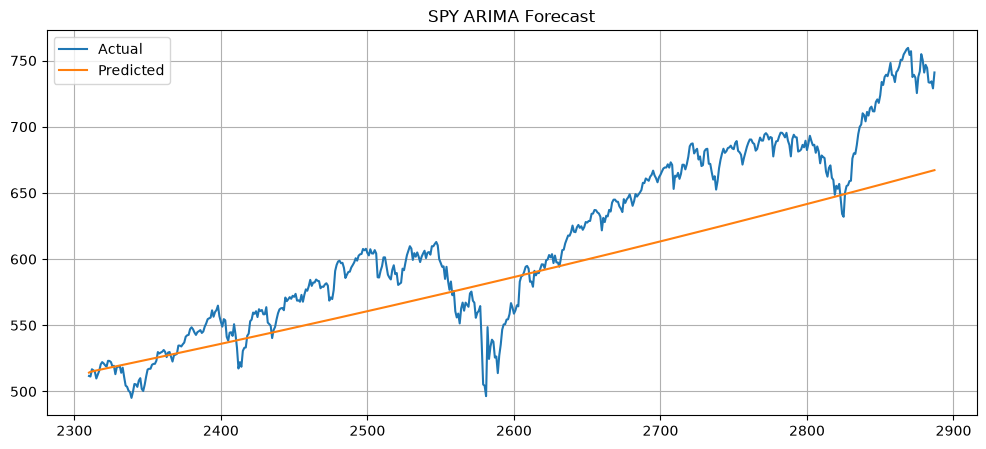


Dataset: BND


c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best Order: (3, 0, 2)
MAE : 1.8235034167861208
RMSE: 2.133244382103637
MAPE: 2.471913846212915


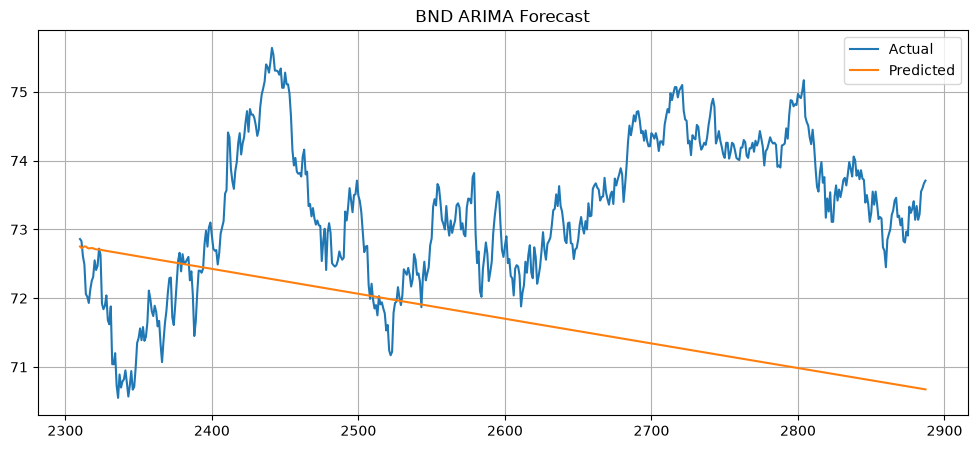

In [11]:
for name in arima_train.keys():

    print("\n" + "="*70)
    print(f"Dataset: {name}")
    print("="*70)

    train = arima_train[name]
    test = arima_test[name]

    # -----------------------------
    # Grid Search ARIMA
    # -----------------------------
    model, order = arima_model.grid_search(train)

    print("Best Order:", order)

    # -----------------------------
    # Forecast Returns
    # -----------------------------
    forecast = arima_model.forecast(len(test))

    forecast = pd.Series(forecast, index=test.index)

    # -----------------------------
    # Convert Return → Close Price
    # -----------------------------
    last_close = train_data[name]["Close"].iloc[-1]

    predicted_close = []
    current = last_close

    for r in forecast:

        current = current * (1 + r)
        predicted_close.append(current)

    predicted_close = pd.Series(
        predicted_close,
        index=test_data[name]["Close"].index
    )

    actual_close = test_data[name]["Close"]

    # -----------------------------
    # Evaluation on Close Price
    # -----------------------------
    mae, rmse, mape = evaluator.metrics(
        actual_close,
        predicted_close
    )

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)

    # -----------------------------
    # Save results
    # -----------------------------
    arima_results[name] = {
        "model": model,
        "order": order,
        "forecast": predicted_close,
        "actual": actual_close,
        "mae": mae,
        "rmse": rmse,
        "mape": mape
    }

    comparison.append({
        "Dataset": name,
        "Model": "ARIMA",
        "Order": order,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

    # -----------------------------
    # Plot
    # -----------------------------
    viz.plot_forecast(
        actual_close,
        predicted_close,
        f"{name} ARIMA Forecast"
    )

In [12]:
comparison_df = pd.DataFrame(comparison)

comparison_df

,Dataset,Model,Order,MAE,RMSE,MAPE
0,TSLA,ARIMA,"(2, 0, 2)",46.856888,65.779570,13.189404
1,SPY,ARIMA,"(3, 0, 2)",32.309484,39.332080,5.030781
2,BND,ARIMA,"(3, 0, 2)",1.823503,2.133244,2.471914


In [13]:
comparison_df.to_csv(
    "../data/output/arima_results.csv",
    index=False
)

print("ARIMA results saved.")

ARIMA results saved.


In [14]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path("../").resolve()

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

for name, result in arima_results.items():

    joblib.dump(
        result["model"],
        MODEL_DIR / f"{name}_ARIMA.pkl"
    )

    print(f"Saved {name}")

Saved TSLA
Saved SPY
Saved BND


In [15]:
best = comparison_df.sort_values("RMSE").iloc[0]

print("="*60)
print("BEST ARIMA MODEL")
print("="*60)
print(best)

BEST ARIMA MODEL
Dataset          BND
Model          ARIMA
Order      (3, 0, 2)
MAE         1.823503
RMSE        2.133244
MAPE        2.471914
Name: 2, dtype: object


In [16]:
lstm_builder = TimeSeriesLSTM()
evaluator = Evaluator()
viz = Visualizer()

In [17]:
lstm_results = []
lstm_models = {}

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


Processing TSLA

Epochs=20, Batch=16



c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 18.
Validation Loss = 0.000663

Epochs=20, Batch=32
Restoring model weights from the end of the best epoch: 19.
Validation Loss = 0.000744

Epochs=30, Batch=16
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 12.
Validation Loss = 0.000711

Epochs=30, Batch=32
Restoring model weights from the end of the best epoch: 24.
Validation Loss = 0.000771

Epochs=50, Batch=16
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 36.
Validation Loss = 0.000557

Epochs=50, Batch=32
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 13.
Validation Loss = 0.001005

Best Hyperparameters
---------------------------
Epochs : 50
Batch  : 16
Validation Loss : 0.0005565655883401632

Performance
---------------------------
MAE  : 15.8845
RMSE : 20.4140
MAPE : 4.66%

Hyperparameter Results


,Epochs,Batch Size,Validation Loss
0,20,16,0.000663
1,20,32,0.000744
2,30,16,0.000711
3,30,32,0.000771
4,50,16,0.000557
5,50,32,0.001005


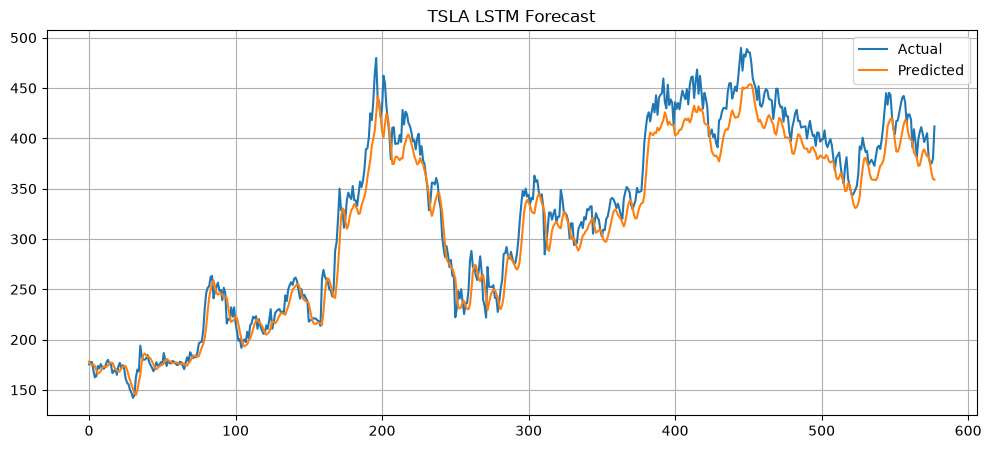


Processing SPY

Epochs=20, Batch=16


c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 20.
Validation Loss = 0.000320

Epochs=20, Batch=32
Restoring model weights from the end of the best epoch: 16.
Validation Loss = 0.000534

Epochs=30, Batch=16
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.
Validation Loss = 0.000928

Epochs=30, Batch=32
Restoring model weights from the end of the best epoch: 23.
Validation Loss = 0.000511

Epochs=50, Batch=16
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.
Validation Loss = 0.000543

Epochs=50, Batch=32
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.
Validation Loss = 0.000800

Best Hyperparameters
---------------------------
Epochs : 20
Batch  : 16
Validation Loss : 0.0003200164355803281

Performance
---------------------------
MAE  : 30.4051
RMSE : 37.0631
MAPE : 4.67%

Hyperparameter Results


,Epochs,Batch Size,Validation Loss
0,20,16,0.000320
1,20,32,0.000534
2,30,16,0.000928
3,30,32,0.000511
4,50,16,0.000543
5,50,32,0.000800


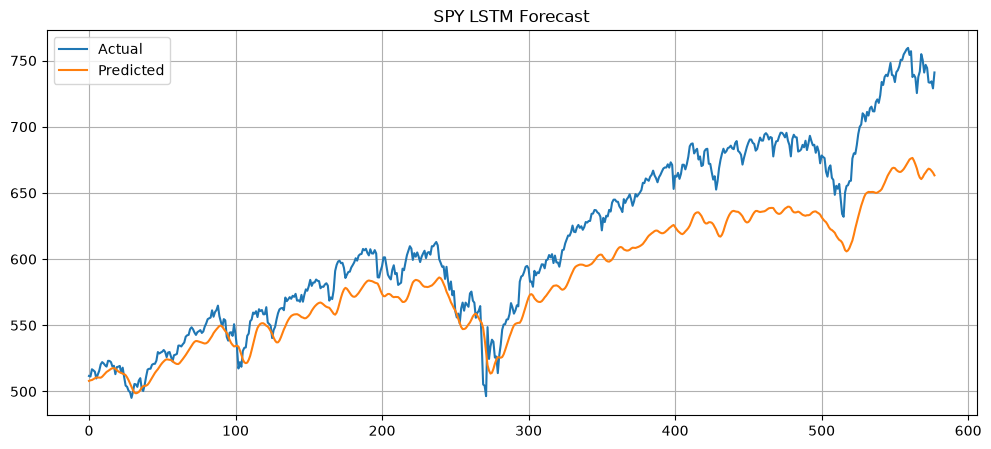


Processing BND

Epochs=20, Batch=16


c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Restoring model weights from the end of the best epoch: 19.
Validation Loss = 0.000658

Epochs=20, Batch=32
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 3.
Validation Loss = 0.001130

Epochs=30, Batch=16
Restoring model weights from the end of the best epoch: 28.
Validation Loss = 0.000625

Epochs=30, Batch=32
Restoring model weights from the end of the best epoch: 29.
Validation Loss = 0.000704

Epochs=50, Batch=16
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 20.
Validation Loss = 0.000684

Epochs=50, Batch=32
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.
Validation Loss = 0.001169

Best Hyperparameters
---------------------------
Epochs : 30
Batch  : 16
Validation Loss : 0.0006251265876926482

Performance
---------------------------
MAE  : 0.2962
RMSE : 0.3647
MAPE : 0.40%

Hyperparameter Results


,Epochs,Batch Size,Validation Loss
0,20,16,0.000658
1,20,32,0.001130
2,30,16,0.000625
3,30,32,0.000704
4,50,16,0.000684
5,50,32,0.001169


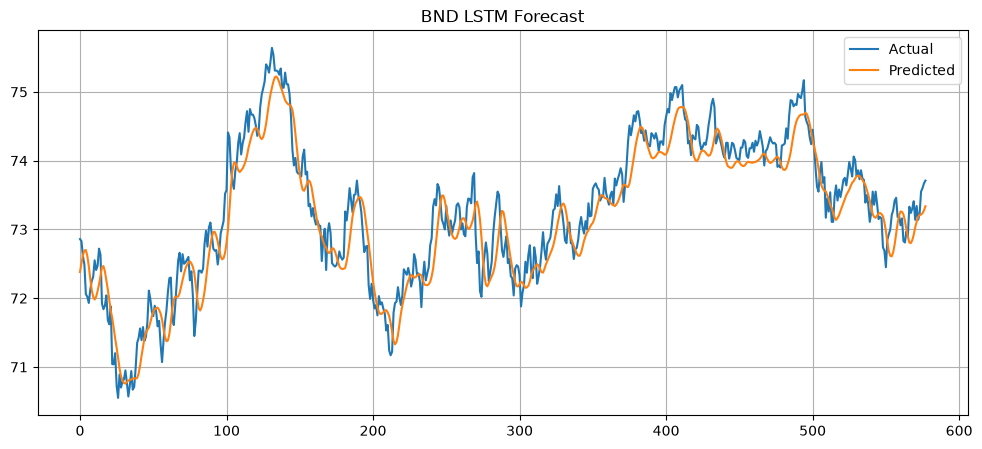

In [19]:
# ==========================================================
# Hyperparameter Tuning + Training LSTM
# ==========================================================

epochs_options = [20, 30, 50]
batch_options = [16, 32]

lstm_results = []
lstm_models = {}

for name in lstm_sequences.keys():

    print("\n" + "="*80)
    print(f"Processing {name}")
    print("="*80)

    X_train = lstm_sequences[name]["X_train"]
    y_train = lstm_sequences[name]["y_train"]

    X_test = lstm_sequences[name]["X_test"]
    y_test = lstm_sequences[name]["y_test"]

    scaler = scalers[name]

    best_model = None
    best_history = None

    best_val_loss = np.inf
    best_epochs = None
    best_batch = None

    tuning_results = []

    # ------------------------------------------
    # Grid Search
    # ------------------------------------------

    for epochs in epochs_options:

        for batch in batch_options:

            print(f"\nEpochs={epochs}, Batch={batch}")

            tf.keras.backend.clear_session()

            model = lstm_builder.build_model(
                input_shape=(X_train.shape[1],1)
            )

            history = model.fit(

                X_train,

                y_train,

                epochs=epochs,

                batch_size=batch,

                validation_split=0.1,

                callbacks=[early_stop],

                verbose=0

            )

            val_loss = min(history.history["val_loss"])

            tuning_results.append({

                "Epochs": epochs,

                "Batch Size": batch,

                "Validation Loss": val_loss

            })

            print(f"Validation Loss = {val_loss:.6f}")

            if val_loss < best_val_loss:

                best_val_loss = val_loss

                best_model = model

                best_history = history

                best_epochs = epochs

                best_batch = batch

    print("\nBest Hyperparameters")

    print("---------------------------")

    print("Epochs :", best_epochs)

    print("Batch  :", best_batch)

    print("Validation Loss :", best_val_loss)

    # ------------------------------------------
    # Prediction
    # ------------------------------------------

    predictions = best_model.predict(
        X_test,
        verbose=0
    )

    predictions = scaler.inverse_transform(
        predictions
    )

    actual = scaler.inverse_transform(
        y_test.reshape(-1,1)
    )

    mae, rmse, mape = evaluator.metrics(
        actual,
        predictions
    )

    print("\nPerformance")

    print("---------------------------")

    print(f"MAE  : {mae:.4f}")

    print(f"RMSE : {rmse:.4f}")

    print(f"MAPE : {mape:.2f}%")

    lstm_models[name] = best_model

    lstm_results.append({

        "Dataset": name,

        "Model": "LSTM",

        "Best Epochs": best_epochs,

        "Best Batch": best_batch,

        "Validation Loss": best_val_loss,

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape

    })

    tuning_df = pd.DataFrame(tuning_results)

    print("\nHyperparameter Results")

    display(tuning_df)

    viz.plot_forecast(
        actual,
        predictions,
        f"{name} LSTM Forecast"
    )

In [20]:
lstm_df = pd.DataFrame(lstm_results)

lstm_df

,Dataset,Model,Best Epochs,Best Batch,Validation Loss,MAE,RMSE,MAPE
0,TSLA,LSTM,50,16,0.000557,15.884482,20.414030,4.660198
1,SPY,LSTM,20,16,0.000320,30.405099,37.063096,4.669141
2,BND,LSTM,30,16,0.000625,0.296181,0.364697,0.404032


In [21]:
os.makedirs("outputs", exist_ok=True)

lstm_df.to_csv(
    "../data/output/lstm_results.csv",
    index=False
)

print("LSTM metrics saved")

LSTM metrics saved


In [22]:
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

for name, model in lstm_models.items():

    model.save(
        MODEL_DIR / f"{name}_LSTM.keras"
    )

    print(f"{name} saved successfully.")

TSLA saved successfully.
SPY saved successfully.
BND saved successfully.


In [23]:
for name in lstm_sequences.keys():

    history = lstm_models[name].history

    if history is None:
        continue

In [24]:
arima_df = pd.read_csv("../data/output/arima_results.csv")
lstm_df = pd.read_csv("../data/output/lstm_results.csv")

print("ARIMA Results")
display(arima_df)

print("LSTM Results")
display(lstm_df)

ARIMA Results


,Dataset,Model,Order,MAE,RMSE,MAPE
0,TSLA,ARIMA,"(2, 0, 2)",46.856888,65.779570,13.189404
1,SPY,ARIMA,"(3, 0, 2)",32.309484,39.332080,5.030781
2,BND,ARIMA,"(3, 0, 2)",1.823503,2.133244,2.471914


LSTM Results


,Dataset,Model,Best Epochs,Best Batch,Validation Loss,MAE,RMSE,MAPE
0,TSLA,LSTM,50,16,0.000557,15.884482,20.414030,4.660198
1,SPY,LSTM,20,16,0.000320,30.405099,37.063096,4.669141
2,BND,LSTM,30,16,0.000625,0.296181,0.364697,0.404032


In [25]:
arima_df["Model"] = "ARIMA"
lstm_df["Model"] = "LSTM"

# Ensure same format
arima_df = arima_df[["Dataset", "Model", "MAE", "RMSE", "MAPE"]]
lstm_df = lstm_df[["Dataset", "Model", "MAE", "RMSE", "MAPE"]]

In [26]:
results = pd.concat([arima_df, lstm_df], ignore_index=True)

results

,Dataset,Model,MAE,RMSE,MAPE
0,TSLA,ARIMA,46.856888,65.779570,13.189404
1,SPY,ARIMA,32.309484,39.332080,5.030781
2,BND,ARIMA,1.823503,2.133244,2.471914
3,TSLA,LSTM,15.884482,20.414030,4.660198
4,SPY,LSTM,30.405099,37.063096,4.669141
5,BND,LSTM,0.296181,0.364697,0.404032


In [27]:
best_per_dataset = results.loc[
    results.groupby("Dataset")["RMSE"].idxmin()
]

best_per_dataset

,Dataset,Model,MAE,RMSE,MAPE
5,BND,LSTM,0.296181,0.364697,0.404032
4,SPY,LSTM,30.405099,37.063096,4.669141
3,TSLA,LSTM,15.884482,20.414030,4.660198


In [28]:
best_overall = results.sort_values("RMSE").iloc[0]

print("="*60)
print("OVERALL BEST MODEL")
print("="*60)
print(best_overall)

OVERALL BEST MODEL
Dataset         BND
Model          LSTM
MAE        0.296181
RMSE       0.364697
MAPE       0.404032
Name: 5, dtype: object


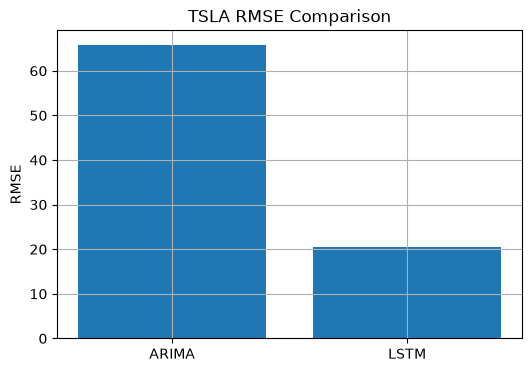

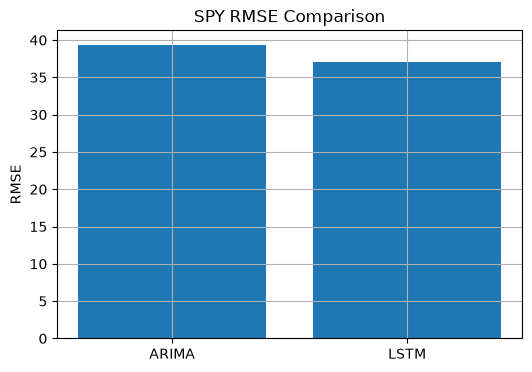

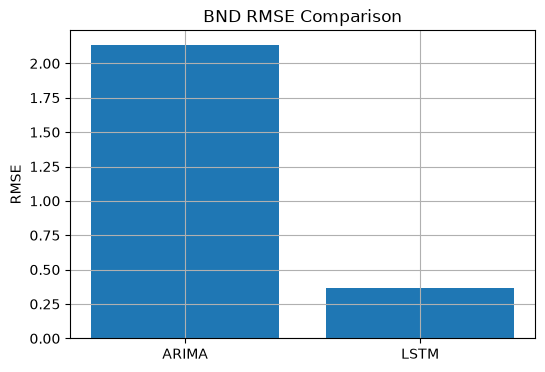

In [29]:
for dataset in results["Dataset"].unique():

    subset = results[results["Dataset"] == dataset]

    plt.figure(figsize=(6,4))

    plt.bar(subset["Model"], subset["RMSE"])

    plt.title(f"{dataset} RMSE Comparison")

    plt.ylabel("RMSE")

    plt.grid(True)

    plt.show()

In [30]:
import os

os.makedirs("outputs", exist_ok=True)

results.to_csv("../data/output/final_comparison.csv", index=False)

best_per_dataset.to_csv("../data/output/best_models.csv", index=False)

print("Final outputs saved.")

Final outputs saved.
